# Exploratory Data Analysis

Out target here is to understand the dataset we have used, telco_churn.csv.

In [1]:
# importing all the necessary libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading and Cleaning

In [2]:
# 1. Loading the raw data
sns.set_theme(style="whitegrid", palette="muted")
df=pd.read_csv('telco_churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
### As we don't require customerID column, we shall drop it

df=df.drop('customerID', axis=1)

In [7]:
## We find that TotalCharges column contains numerical data as data type str. 

df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [9]:
# We drop the missing data of TotalCharges as it is very small compare to total dataset.

df.dropna(subset=['TotalCharges'],inplace=True)

    Categorical Columns: SeniorCitizen, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, 
                         DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, Churn


    Numerical Columns: tenure, MonthlyCharges, TotalCharges

### Feature Engineering

In [10]:
# We change the data type of few columns to save memory space


df['SeniorCitizen']=df['SeniorCitizen'].astype('int32')
df['tenure']=df['tenure'].astype('int32')
df['MonthlyCharges']=df['MonthlyCharges'].astype('float32')
df['TotalCharges']=df['TotalCharges'].astype('float32')

#### We make a new column name Total_addnos for better analysis

+ All service mentioned are columns we can add together to understand the friction of extra service on the Churn rate.

In [11]:
def total_addons(row):
    addon_count=0
    addon_cols=['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    for col in addon_cols:
        if row[col].lower() =='yes':
            addon_count+=1
    return addon_count

In [12]:
df['Total_addons']=df.apply(total_addons, axis=1)
df['Total_addons']=df['Total_addons'].astype('int32')
df['Total_addons'].value_counts()

Total_addons
0    2213
3    1117
2    1033
1     966
4     850
5     569
6     284
Name: count, dtype: int64

+ We add a column name services, to understand if the customer has opted for Internet Services, Phone Services or both Services. Added column is to understand how the type of Services affect the Churn rate

In [13]:
def services(row):
    phone=row['PhoneService']
    internet=row['InternetService']
    if (phone == 'Yes') and (internet != 'No'):
        return 'P&I' 
    elif (phone == 'No') and (internet != 'No'):
        return 'I' 
    else:
        return 'P'


In [14]:
df['Services']=df.apply(services, axis=1)
df['Services'].value_counts()

Services
P&I    4832
P      1520
I       680
Name: count, dtype: int64

+ We add the column Tenure_Group to classify tenure into three categories:
    * Veteran: Customers who has been with the company for more than or equal to 48 months.
    * Loyal: Customers who has been with the company for 13 to 47 months.
    * New Customer: Customer who has been with the company for less than or equal to 12 months.
+ We use this column to understand impact of tenure type on the Churn.

In [15]:
def tenure_dem(num):
    if num>=48:
        return 'Veteran'
    elif num<48 and num>=13:
        return 'Loyal'
    else:
        return 'New Customer'

In [16]:
df['Tenure_Group']=df['tenure'].apply(tenure_dem)

### Univariate Analysis

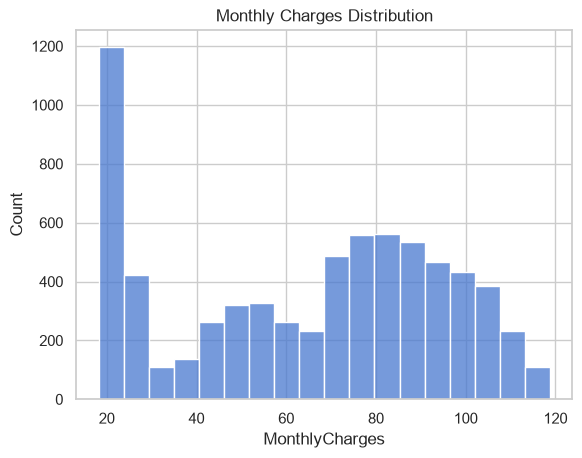

In [17]:
plt.title('Monthly Charges Distribution')
sns.histplot(data=df, x='MonthlyCharges')
plt.show()

* From above graph we get insights on how MonthlyCharges column:
    + Most customers are monthly charged around $20 for the Services.

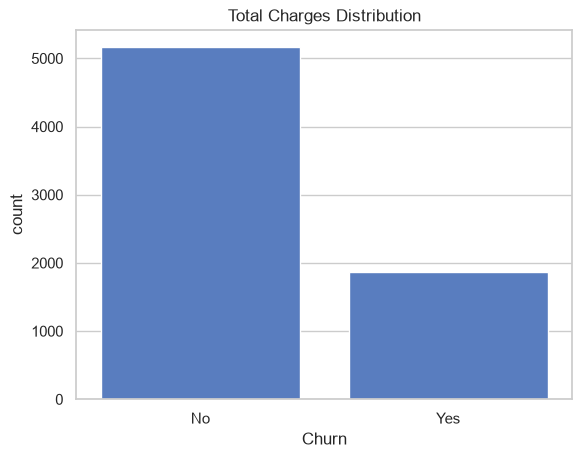

In [18]:
# Understanding the distribution of Churn(Target Column)
plt.title('Total Charges Distribution')
sns.countplot(data=df, x='Churn')
plt.show()

From above graph we can conclude that the dataset is unbalanced.

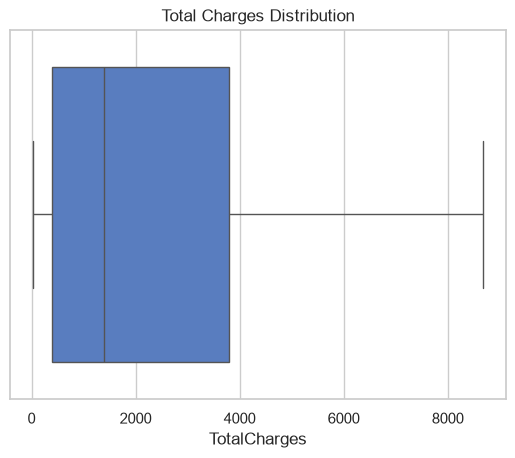

In [19]:
# Box Plot to find Outliers in TotalCharges
plt.title('Total Charges Distribution')
sns.boxplot(data=df, x='TotalCharges')
plt.show()

There are no outliers in TotalCharges column

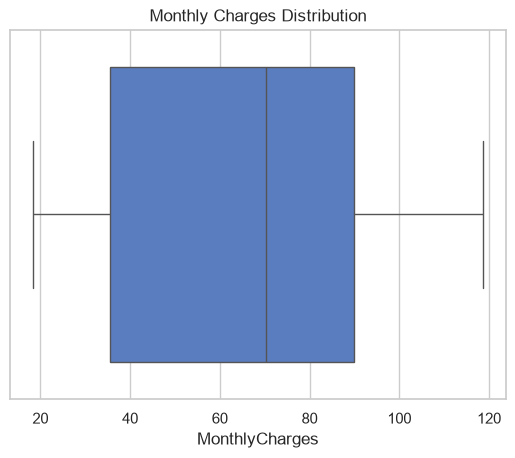

In [20]:
# Box Plot to find Outliers in MonthlyCharges
plt.title('Monthly Charges Distribution')
sns.boxplot(data=df, x='MonthlyCharges')
plt.show()

No outliers in MonthlyCharges column

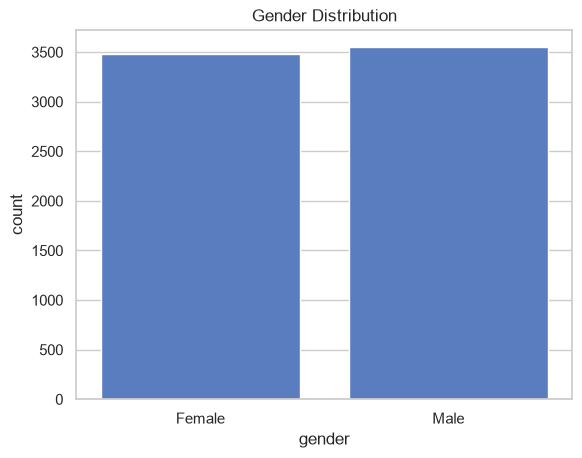

In [21]:
# Countplot to under data of distribution based on Gender
plt.title('Gender Distribution')
sns.countplot(data=df, x='gender')
plt.show()

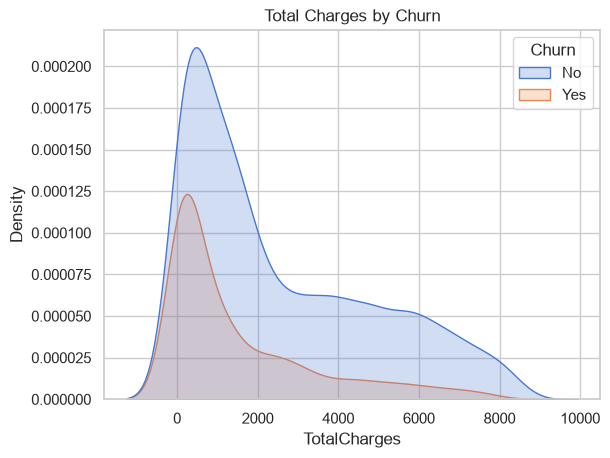

In [22]:
# Understand the relation between TotalCharges and Churn
plt.title('Total Charges by Churn')
sns.kdeplot(data=df, x='TotalCharges', hue='Churn', fill=True)
plt.show()

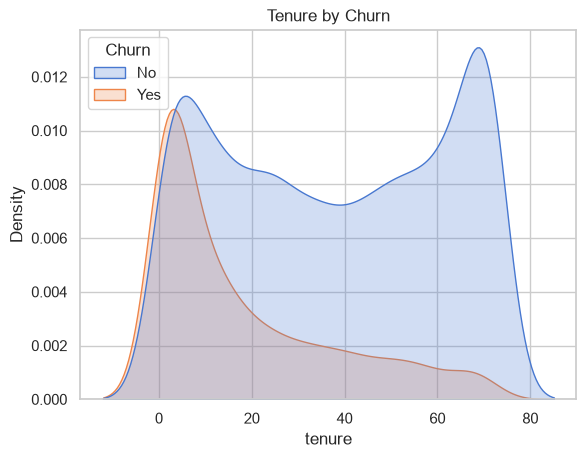

In [23]:
# Understand the relation between Tenure and Churn
plt.title('Tenure by Churn')
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True)
plt.show()

#### Bivariate Analysis

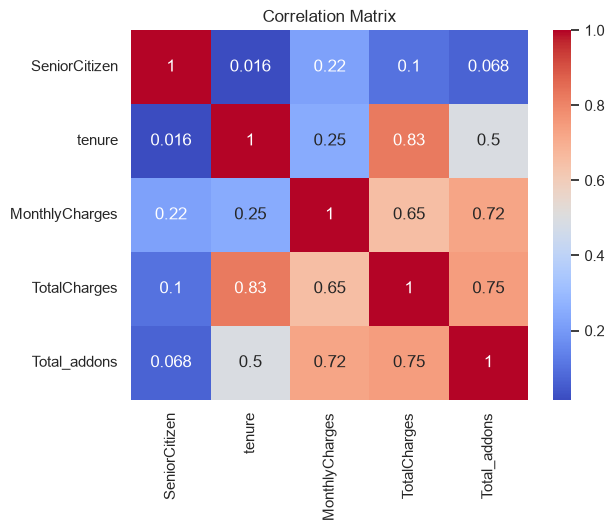

In [24]:
# Understanding the correlation between different features

plt.title('Correlation Matrix')
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

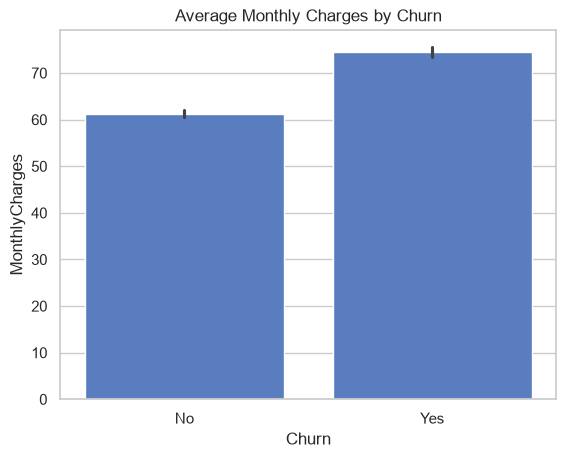

In [25]:
# Understand the relation between MonthlyCharges and Churn
plt.title('Average Monthly Charges by Churn')
sns.barplot(data=df, x='Churn', y='MonthlyCharges')
plt.show()

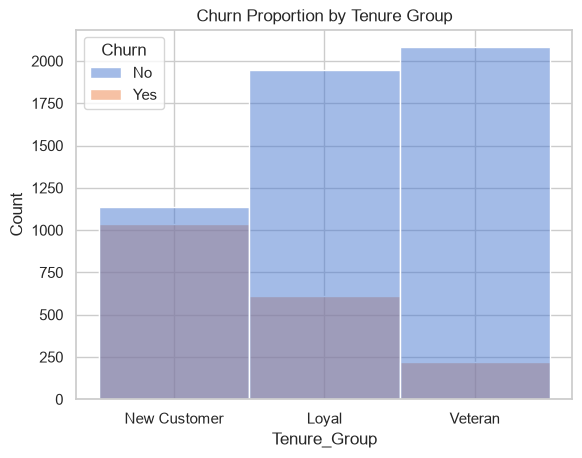

In [26]:
# Understanding the relation between Tenure group and Churn
plt.title('Churn Proportion by Tenure Group')
sns.histplot(data=df, x='Tenure_Group', hue='Churn')
plt.show()

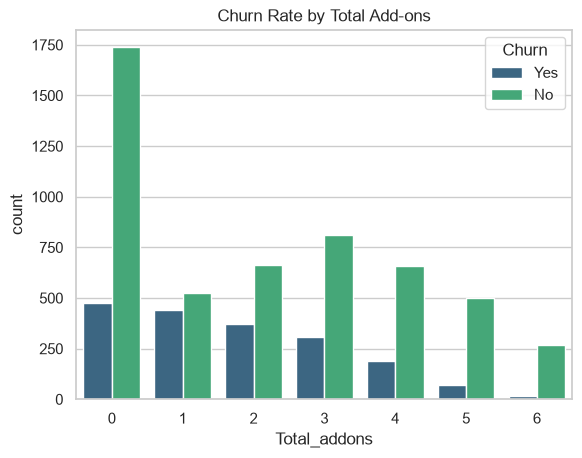

In [27]:
# Understanding relation of Total_addones for Churn
plt.title('Churn Rate by Total Add-ons')
sns.countplot(data=df, x='Total_addons', hue='Churn', palette='viridis')
plt.show()

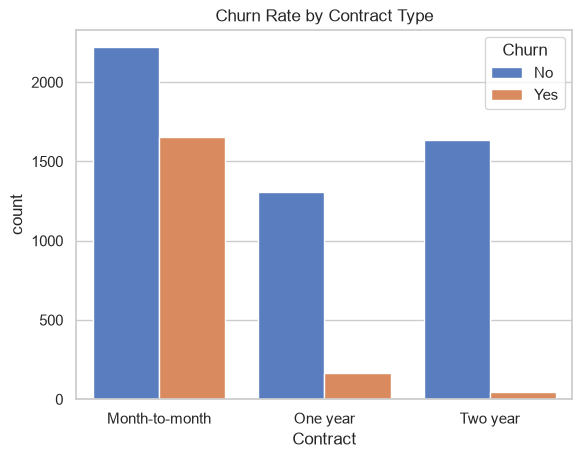

In [28]:
plt.title('Churn Rate by Contract Type')
sns.countplot(data=df, x='Contract', hue='Churn')
plt.show()

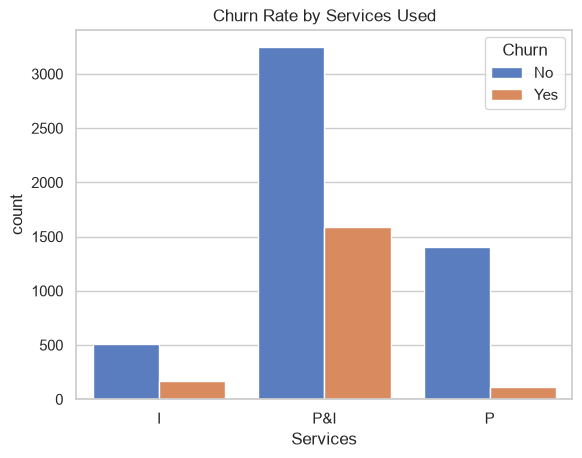

In [29]:
plt.title('Churn Rate by Services Used')
sns.countplot(data=df, x='Services', hue='Churn')
plt.show()

<Axes: >

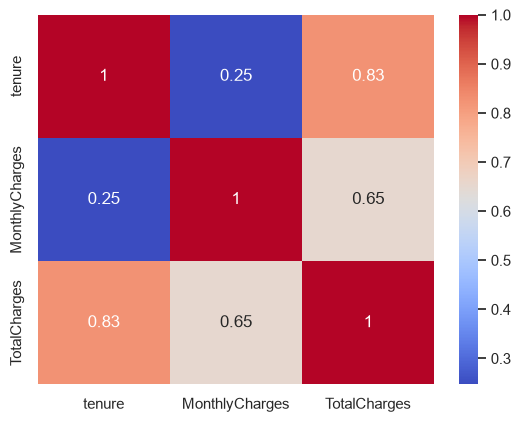

In [30]:
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), cmap='coolwarm', annot=True)

### Saving the file for further steps

In [31]:
df.to_csv('engineered_telco_churn.csv', index=False)

# THE END OF EDA NOTEBOOK